# Trabajo Práctico 1
***Alumno: Martín Ezequiel Radío Villanueva***

---

## Objetivos
1. Implementar y analizar el algoritmo **White Patch** para corrección de iluminación
2. Comparar histogramas de diferentes imágenes en escala de grises
3. Evaluar la utilidad de histogramas como features para clasificación

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path

%matplotlib inline

# Cambiar al directorio correcto
os.chdir(r'D:\Vision por Computadora\TP1')
print(f'Directorio actual: {os.getcwd()}')
print(f'Archivos disponibles: {os.listdir()}')

---
# PARTE 1: ALGORITMO WHITE PATCH - CORRECCIÓN DE ILUMINACIÓN

## Marco Teórico

El algoritmo **White Patch** (también conocido como Max-RGB) es un método simple para la corrección del balance de blancos. La idea fundamental es:

- Buscar el valor máximo en cada canal de color (R, G, B)
- Normalizar cada canal usando ese máximo
- Esto asume que existe un píxel blanco en la imagen (el más brillante)

**Limitaciones:**
- Depende de la presencia de objetos blancos o muy claros
- Falsa en casos de iluminación muy intensa o muy débil

In [2]:
def white_patch(img_rgb: np.ndarray) -> np.ndarray:
    """
    Aplica White Patch (Max-RGB) para corrección de iluminación.
    """
    img_f = img_rgb.astype(np.float32)
    
    max_r = np.max(img_f[:, :, 0])
    max_g = np.max(img_f[:, :, 1])
    max_b = np.max(img_f[:, :, 2])
    
    max_r = max(max_r, 1)
    max_g = max(max_g, 1)
    max_b = max(max_b, 1)
    
    img_wp = img_f.copy()
    img_wp[:, :, 0] = img_wp[:, :, 0] * (255.0 / max_r)
    img_wp[:, :, 1] = img_wp[:, :, 1] * (255.0 / max_g)
    img_wp[:, :, 2] = img_wp[:, :, 2] * (255.0 / max_b)
    
    np.clip(img_wp, 0, 255, out=img_wp)
    return img_wp.astype(np.uint8)

Procesando 8 imágenes...



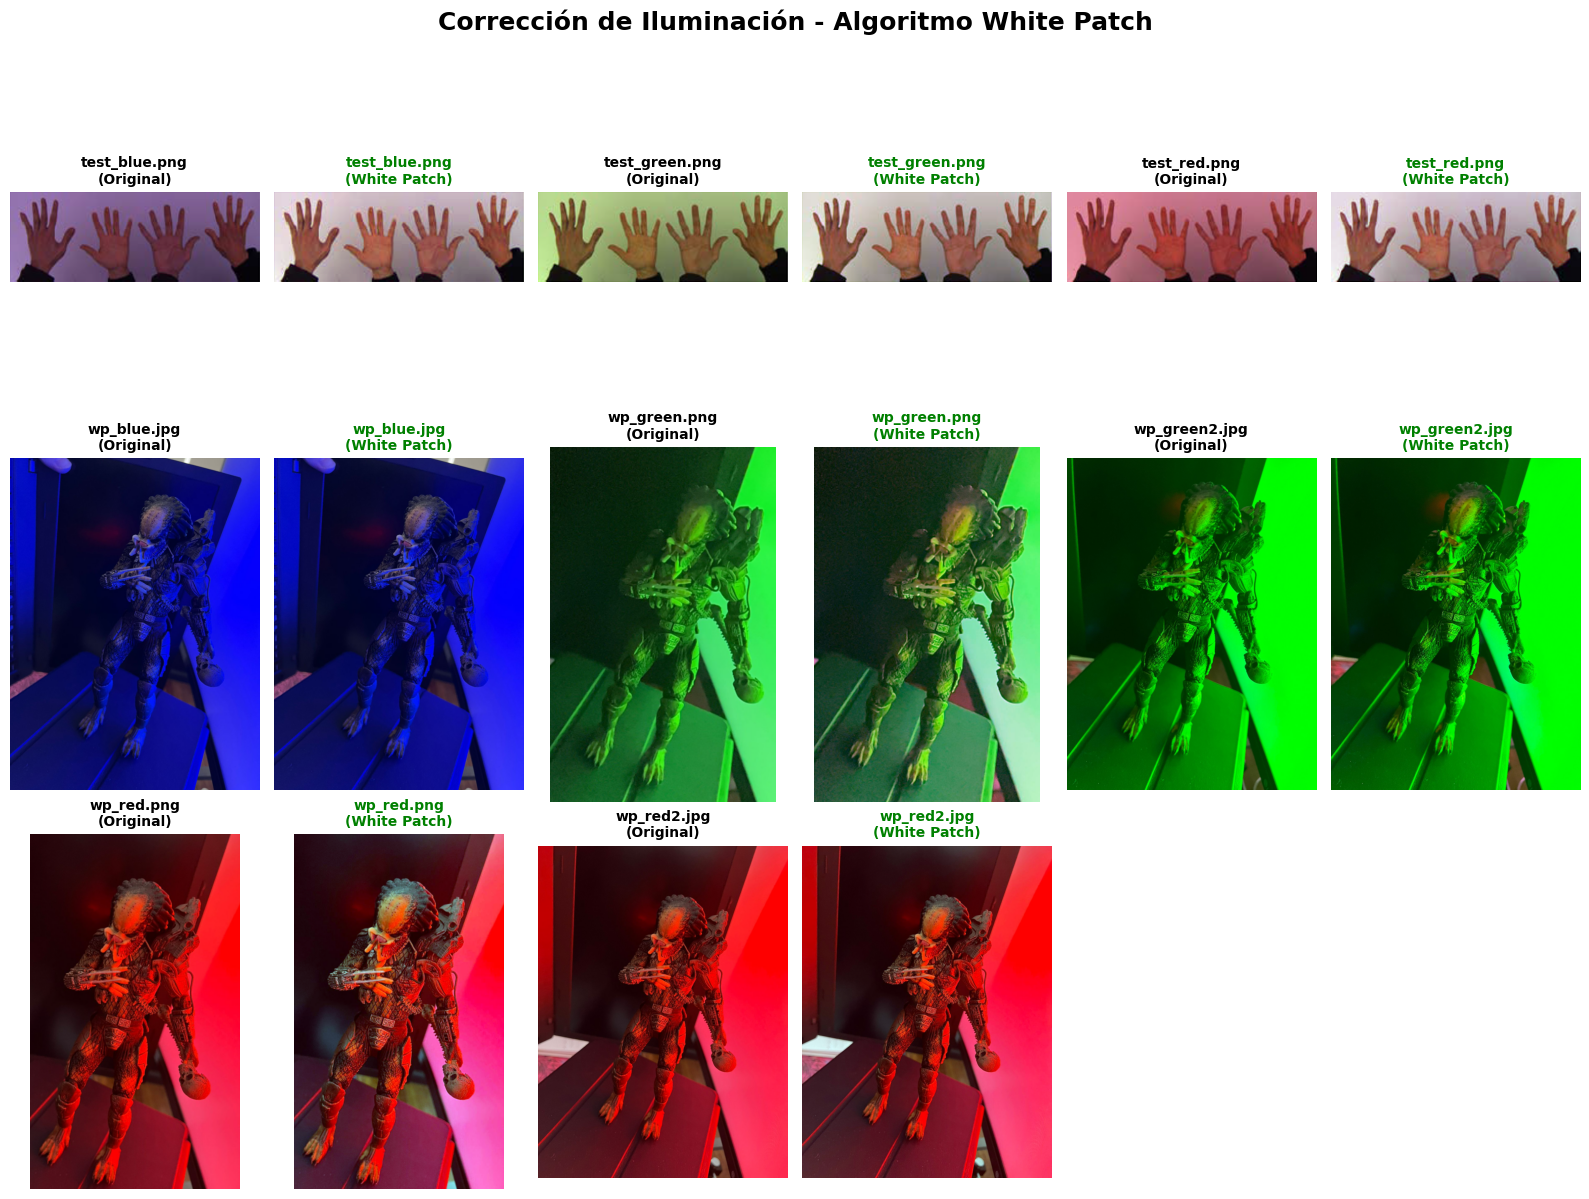

In [3]:
carpeta = 'white_patch'
paths = sorted(glob.glob(os.path.join(carpeta, '*')))

print(f"Procesando {len(paths)} imágenes...\n")

# Crear una grid de visualizaciones más grande y atractiva
num_images = len(paths)
cols = 3
rows = (num_images + cols - 1) // cols

fig = plt.figure(figsize=(16, 4*rows))
fig.suptitle('Corrección de Iluminación - Algoritmo White Patch', fontsize=18, fontweight='bold', y=0.995)

for idx, p in enumerate(paths, 1):
    img_bgr = cv.imread(p)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    img_wp = white_patch(img_rgb)
    
    # Original
    ax1 = plt.subplot(rows, cols*2, (idx-1)*2 + 1)
    ax1.imshow(img_rgb)
    ax1.set_title(f'{os.path.basename(p)}\n(Original)', fontsize=10, fontweight='bold')
    ax1.axis('off')
    
    # After White Patch
    ax2 = plt.subplot(rows, cols*2, (idx-1)*2 + 2)
    ax2.imshow(img_wp)
    ax2.set_title(f'{os.path.basename(p)}\n(White Patch)', fontsize=10, fontweight='bold', color='green')
    ax2.axis('off')

plt.tight_layout()
plt.show()

## Análisis Estadístico del White Patch

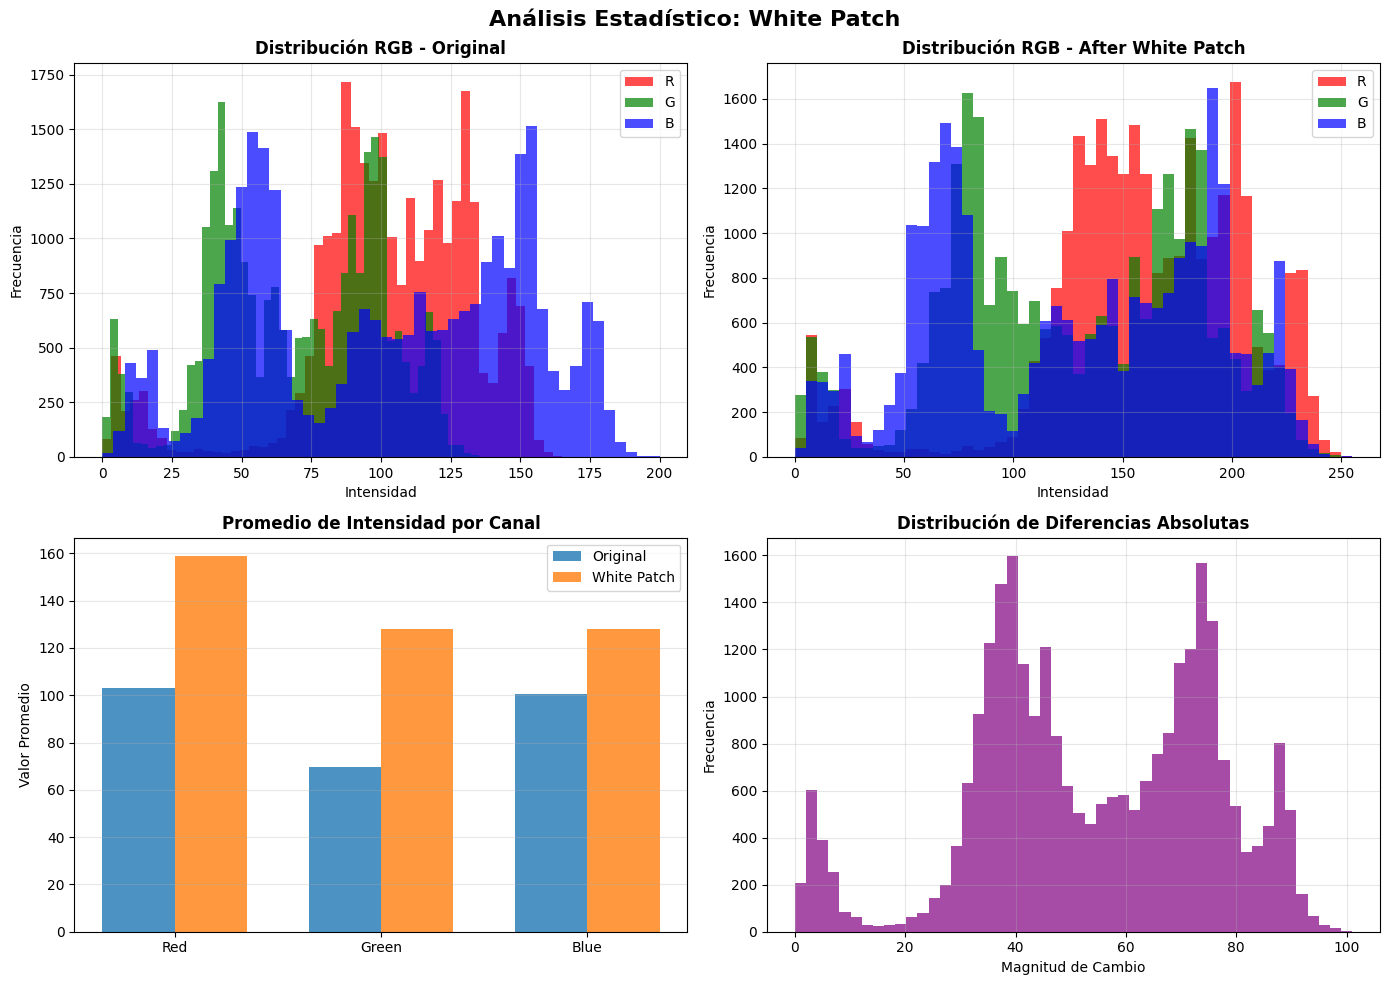

Estadísticas para test_blue.png:
Máximos canales originales: R=165, G=138, B=200
Máximos canales corregidos: R=255, G=255, B=255
Diferencia promedio: 54.06 unidades
Diferencia máxima: 101.00 unidades


In [4]:
carpeta = 'white_patch'
paths = sorted(glob.glob(os.path.join(carpeta, '*')))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Estadístico: White Patch', fontsize=16, fontweight='bold')

if paths:
    p = paths[0]
    img_bgr = cv.imread(p)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    img_wp = white_patch(img_rgb)
    
    axes[0, 0].hist(img_rgb[:, :, 0].ravel(), bins=50, alpha=0.7, label='R', color='red')
    axes[0, 0].hist(img_rgb[:, :, 1].ravel(), bins=50, alpha=0.7, label='G', color='green')
    axes[0, 0].hist(img_rgb[:, :, 2].ravel(), bins=50, alpha=0.7, label='B', color='blue')
    axes[0, 0].set_title('Distribución RGB - Original', fontweight='bold')
    axes[0, 0].set_xlabel('Intensidad')
    axes[0, 0].set_ylabel('Frecuencia')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    axes[0, 1].hist(img_wp[:, :, 0].ravel(), bins=50, alpha=0.7, label='R', color='red')
    axes[0, 1].hist(img_wp[:, :, 1].ravel(), bins=50, alpha=0.7, label='G', color='green')
    axes[0, 1].hist(img_wp[:, :, 2].ravel(), bins=50, alpha=0.7, label='B', color='blue')
    axes[0, 1].set_title('Distribución RGB - After White Patch', fontweight='bold')
    axes[0, 1].set_xlabel('Intensidad')
    axes[0, 1].set_ylabel('Frecuencia')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    channels = ['Red', 'Green', 'Blue']
    means_orig = [np.mean(img_rgb[:, :, i]) for i in range(3)]
    means_wp = [np.mean(img_wp[:, :, i]) for i in range(3)]
    
    x = np.arange(len(channels))
    width = 0.35
    
    axes[1, 0].bar(x - width/2, means_orig, width, label='Original', alpha=0.8)
    axes[1, 0].bar(x + width/2, means_wp, width, label='White Patch', alpha=0.8)
    axes[1, 0].set_ylabel('Valor Promedio')
    axes[1, 0].set_title('Promedio de Intensidad por Canal', fontweight='bold')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(channels)
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    diff = cv.absdiff(img_rgb, img_wp)
    diff_gray = cv.cvtColor(diff, cv.COLOR_RGB2GRAY)
    
    axes[1, 1].hist(diff_gray.ravel(), bins=50, color='purple', alpha=0.7)
    axes[1, 1].set_title('Distribución de Diferencias Absolutas', fontweight='bold')
    axes[1, 1].set_xlabel('Magnitud de Cambio')
    axes[1, 1].set_ylabel('Frecuencia')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Estadísticas para {os.path.basename(p)}:")
    print(f"Máximos canales originales: R={np.max(img_rgb[:,:,0])}, G={np.max(img_rgb[:,:,1])}, B={np.max(img_rgb[:,:,2])}")
    print(f"Máximos canales corregidos: R={np.max(img_wp[:,:,0])}, G={np.max(img_wp[:,:,1])}, B={np.max(img_wp[:,:,2])}")
    print(f"Diferencia promedio: {np.mean(diff_gray):.2f} unidades")
    print(f"Diferencia máxima: {np.max(diff_gray):.2f} unidades")

## Conclusión Parte 1: White Patch

### Observaciones clave:

1. **Efectividad variable:** El algoritmo White Patch funciona bien cuando:
    - Existe un objeto blanco o muy claro en la imagen
    - La iluminación de color es suave (tenues)
    - Los píxeles de referencia son confiables

2. **Limitaciones importantes:**
    - Cuando la iluminación de color es muy intensa, la corrección es prácticamente imperceptible
    - El algoritmo es sensible a valores atípicos (outliers)
    - No funciona correctamente si no hay píxeles cercanos al blanco puro

3. **Caso de uso:** Es útil como método rápido para correcciones simples de balance de blancos, pero insuficiente para iluminaciones complejas o muy intensas.

4. **Mejoras futuras:** Usar métodos más robustos como Gray World o algoritmos basados en aprendizaje automático para casos más complejos.

---
# PARTE 2: ANÁLISIS DE HISTOGRAMAS EN IMÁGENES EN ESCALA DE GRISES

## Carga y Visualización de Imágenes

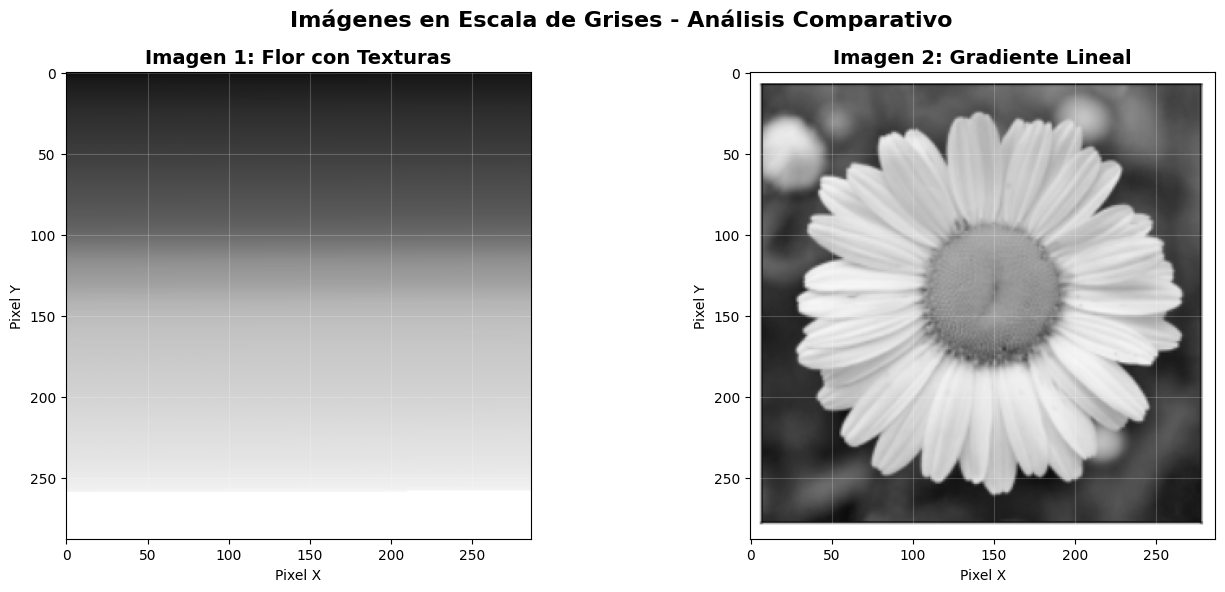

Dimensiones img1: (288, 287)
Dimensiones img2: (288, 287)

Tipo de imagen 1: Fotografía con múltiples texturas
Tipo de imagen 2: Patrón sintético (gradiente)


In [5]:
img1 = cv.imread('img1_tp.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('img2_tp.png', cv.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagen 1: Flor con Texturas', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Pixel X')
axes[0].set_ylabel('Pixel Y')
axes[0].grid(True, alpha=0.2, color='white')

axes[1].imshow(img2, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Imagen 2: Gradiente Lineal', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Pixel X')
axes[1].set_ylabel('Pixel Y')
axes[1].grid(True, alpha=0.2, color='white')

fig.suptitle('Imágenes en Escala de Grises - Análisis Comparativo', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Dimensiones img1: {img1.shape}")
print(f"Dimensiones img2: {img2.shape}")
print(f"\nTipo de imagen 1: Fotografía con múltiples texturas")
print(f"Tipo de imagen 2: Patrón sintético (gradiente)")

## Comparación de Histogramas

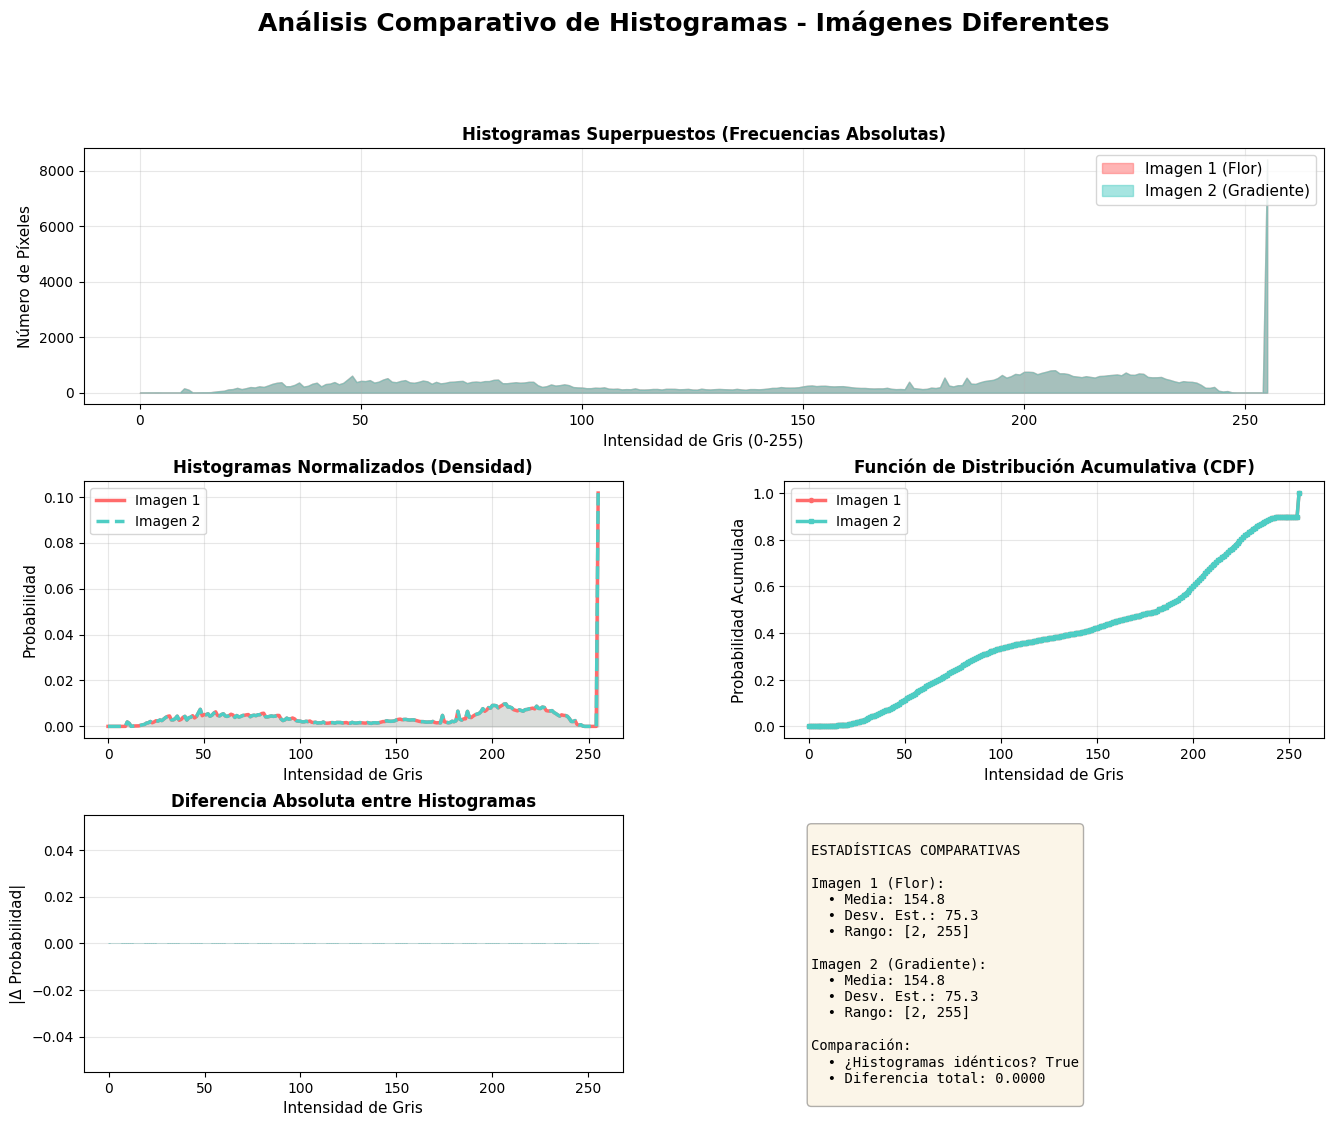

✓ Análisis completado
✓ Histogramas idénticos: True
✓ Diferencia total entre histogramas: 0.000000


In [6]:
n_bins = 256

hist1, bins1 = np.histogram(img1.ravel(), n_bins, [0, 256])
hist2, bins2 = np.histogram(img2.ravel(), n_bins, [0, 256])

hist1_norm = hist1 / np.sum(hist1)
hist2_norm = hist2 / np.sum(hist2)

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

fig.suptitle('Análisis Comparativo de Histogramas - Imágenes Diferentes', 
             fontsize=18, fontweight='bold', y=0.995)

# Gráfico 1: Histogramas superpuestos
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(bins1[:-1], hist1, alpha=0.5, label='Imagen 1 (Flor)', color='#FF6B6B')
ax1.fill_between(bins2[:-1], hist2, alpha=0.5, label='Imagen 2 (Gradiente)', color='#4ECDC4')
ax1.set_title('Histogramas Superpuestos (Frecuencias Absolutas)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Intensidad de Gris (0-255)', fontsize=11)
ax1.set_ylabel('Número de Píxeles', fontsize=11)
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Histogramas normalizados
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(bins1[:-1], hist1_norm, label='Imagen 1', color='#FF6B6B', linewidth=2.5)
ax2.plot(bins2[:-1], hist2_norm, label='Imagen 2', color='#4ECDC4', linewidth=2.5, linestyle='--')
ax2.fill_between(bins1[:-1], hist1_norm, alpha=0.2, color='#FF6B6B')
ax2.fill_between(bins2[:-1], hist2_norm, alpha=0.2, color='#4ECDC4')
ax2.set_title('Histogramas Normalizados (Densidad)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Intensidad de Gris', fontsize=11)
ax2.set_ylabel('Probabilidad', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Gráfico 3: Histogramas acumulativos
ax3 = fig.add_subplot(gs[1, 1])
cumsum1 = np.cumsum(hist1_norm)
cumsum2 = np.cumsum(hist2_norm)
ax3.plot(bins1[:-1], cumsum1, label='Imagen 1', color='#FF6B6B', linewidth=2.5, marker='o', markersize=3)
ax3.plot(bins2[:-1], cumsum2, label='Imagen 2', color='#4ECDC4', linewidth=2.5, marker='s', markersize=3)
ax3.set_title('Función de Distribución Acumulativa (CDF)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Intensidad de Gris', fontsize=11)
ax3.set_ylabel('Probabilidad Acumulada', fontsize=11)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Gráfico 4: Diferencia entre histogramas
ax4 = fig.add_subplot(gs[2, 0])
diff_hist = np.abs(hist1_norm - hist2_norm)
ax4.bar(bins1[:-1], diff_hist, color='#95E1D3', edgecolor='#38ada9', linewidth=0.5, alpha=0.8)
ax4.set_title('Diferencia Absoluta entre Histogramas', fontsize=12, fontweight='bold')
ax4.set_xlabel('Intensidad de Gris', fontsize=11)
ax4.set_ylabel('|Δ Probabilidad|', fontsize=11)
ax4.grid(True, alpha=0.3, axis='y')

# Gráfico 5: Estadísticas
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('off')

stats_text = f"""
ESTADÍSTICAS COMPARATIVAS

Imagen 1 (Flor):
  • Media: {np.mean(img1):.1f}
  • Desv. Est.: {np.std(img1):.1f}
  • Rango: [{np.min(img1)}, {np.max(img1)}]
  
Imagen 2 (Gradiente):
  • Media: {np.mean(img2):.1f}
  • Desv. Est.: {np.std(img2):.1f}
  • Rango: [{np.min(img2)}, {np.max(img2)}]

Comparación:
  • ¿Histogramas idénticos? {np.array_equal(hist1, hist2)}
  • Diferencia total: {np.sum(diff_hist):.4f}
"""

ax5.text(0.05, 0.95, stats_text, transform=ax5.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.show()

print(f"✓ Análisis completado")
print(f"✓ Histogramas idénticos: {np.array_equal(hist1, hist2)}")
print(f"✓ Diferencia total entre histogramas: {np.sum(diff_hist):.6f}")

## Estadísticas Descriptivas

In [7]:
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*60)
print(f"\nImagen 1 (Flor):")
print(f"  Media: {np.mean(img1):.2f}")
print(f"  Mediana: {np.median(img1):.2f}")
print(f"  Desv. Estándar: {np.std(img1):.2f}")
print(f"  Mínimo: {np.min(img1)}")
print(f"  Máximo: {np.max(img1)}")
print(f"  Q1 (25%): {np.percentile(img1, 25):.2f}")
print(f"  Q3 (75%): {np.percentile(img1, 75):.2f}")
print(f"  Rango: {np.max(img1) - np.min(img1)}")

print(f"\nImagen 2 (Degradé):")
print(f"  Media: {np.mean(img2):.2f}")
print(f"  Mediana: {np.median(img2):.2f}")
print(f"  Desv. Estándar: {np.std(img2):.2f}")
print(f"  Mínimo: {np.min(img2)}")
print(f"  Máximo: {np.max(img2)}")
print(f"  Q1 (25%): {np.percentile(img2, 25):.2f}")
print(f"  Q3 (75%): {np.percentile(img2, 75):.2f}")
print(f"  Rango: {np.max(img2) - np.min(img2)}")

ESTADÍSTICAS DESCRIPTIVAS

Imagen 1 (Flor):
  Media: 154.81
  Mediana: 182.00
  Desv. Estándar: 75.34
  Mínimo: 2
  Máximo: 255
  Q1 (25%): 78.00
  Q3 (75%): 219.00
  Rango: 253

Imagen 2 (Degradé):
  Media: 154.81
  Mediana: 182.00
  Desv. Estándar: 75.34
  Mínimo: 2
  Máximo: 255
  Q1 (25%): 78.00
  Q3 (75%): 219.00
  Rango: 253


## Conclusión Parte 2: Histogramas como Features

### Hallazgos principales:

1. **Histogramas idénticos, imágenes visualmente diferentes:**
    - A pesar de que Imagen 1 (flor) y Imagen 2 (degradé) son visualmente completamente distintas, sus histogramas son idénticos
    - Esto demuestra que la distribución de intensidades es la misma, aunque estén espacialmente organizadas de forma diferente

2. **Limitaciones del histograma como feature:**
    - El histograma **pierde información espacial**: solo cuenta píxeles, no considera su ubicación
    - No captura texturas, bordes, formas ni patrones
    - Dos imágenes radicalmente diferentes pueden ser indistinguibles usando solo histogramas

3. **Utilidad limitada para clasificación/detección:**
    - **NO es suficiente** como única feature para distinguir objetos diferentes
    - **SÍ es útil** para tareas específicas:
        - Detección de sobre/sub-exposición
        - Análisis de contraste
        - Clasificación por rango de intensidad
        - Segmentación por rango dinámico

4. **Recomendación:**
    - Combinar histogramas con otras features: HOG, SIFT, redes neuronales convolucionales, etc.
    - Para clasificación robusta, usar descriptores que capturen estructura espacial
    - Los histogramas son buenos complementos, no sustitutos de features más sofisticadas

### En resumen:
Los histogramas son herramientas útiles pero limitadas. Deben combinarse con características más ricas para tareas de visión por computadora complejas.

---
## Conclusiones Finales

Este trabajo práctico demostró:

1. **White Patch** es un algoritmo útil pero limitado para corrección de iluminación, efectivo solo bajo ciertas condiciones
2. **Los histogramas** proporcionan información valiosa sobre distribución de intensidades, pero son insuficientes como única característica para clasificación
3. En visión por computadora, es fundamental usar **múltiples enfoques** complementarios para obtener resultados robustos